<div style="
    background: linear-gradient(135deg, #F5F3FF 0%, #FFF7ED 100%);
    border: 1px solid #E9D5FF;
    border-radius: 18px;
    padding: 24px 28px;
    margin-bottom: 20px;
">

<span style="color:#7C3AED; font-size:14px; font-weight:700;">
WEEK 7 · DEEP LEARNING · DAY 3
</span>

<h1 style="color:#1E293B; margin:8px 0 6px 0;">
RNNs & LSTMs for Sequential Data
</h1>

<p style="color:#475569; font-size:15px; margin:0;">
Understanding how recurrent neural networks use memory to learn patterns from sequential ECG signals.
</p>

</div>

<div style="
    background:#F8FAFC;
    border-left:4px solid #3B82F6;
    border-radius:12px;
    padding:16px 18px;
    margin:16px 0;
">

<h2 style="color:#1D4ED8; margin-top:0;">
Where Did Day 2 Leave Off?
</h2>

<p style="color:#334155;">
Yesterday, I explored how <b style="color:#7C3AED;">Convolutional Neural Networks (CNNs)</b>
learn spatial patterns from image data and how
<b style="color:#EC4899;">Transfer Learning</b> can reuse features learned by a pre-trained model.
</p>

<p style="color:#334155; margin-bottom:0;">
Today, the focus changes from <b style="color:#2563EB;">spatial data</b> to
<b style="color:#059669;">sequential data</b>, where the order of observations carries important information.
</p>

</div>

<div style="
    background:#FFF7ED;
    border:1px solid #FDBA74;
    border-radius:12px;
    padding:15px 18px;
    margin:16px 0;
">

<b style="color:#EA580C;">Today's question:</b>

<span style="color:#334155;">
How can a neural network remember earlier parts of a sequence, and why can an
<b style="color:#7C3AED;">LSTM</b> handle long-term dependencies better than a plain
<b style="color:#2563EB;">RNN</b>?
</span>

</div>

<div style="
    background:#FFF9F2;
    border:1px solid #FED7AA;
    border-radius:14px;
    padding:18px 20px;
    margin:18px 0 28px 0;
">

<h2 style="color:#1E293B; margin-top:0;">
Today's Roadmap
</h2>

<p>
<b style="color:#7C3AED;">01 — Sequential Data:</b>
Why order changes the meaning of a sequence.
</p>

<p>
<b style="color:#EC4899;">02 — RNNs:</b>
How a hidden state carries information through time.
</p>

<p>
<b style="color:#2563EB;">03 — Vanishing Gradients:</b>
Why plain RNNs struggle with long-term dependencies.
</p>

<p>
<b style="color:#059669;">04 — LSTMs & GRUs:</b>
How gated memory helps preserve useful information.
</p>

<p style="margin-bottom:0;">
<b style="color:#EA580C;">05 — Hands-on:</b>
Prepare ECG sequences, train an LSTM, compare it with a plain RNN, and evaluate the results.
</p>

</div>

<div style="
    background:#F5F3FF;
    border-left:5px solid #8B5CF6;
    border-radius:12px;
    padding:15px 18px;
    margin:18px 0 12px 0;
">

<h2 style="color:#7C3AED; margin:0 0 6px 0;">
1. Why Sequential Data Needs a Different Architecture
</h2>

<p style="color:#334155; margin:0;">
Sequential data contains observations arranged in a
<b style="color:#7C3AED;">meaningful order</b>.
Unlike ordinary tabular data, changing that order can change the pattern or meaning of the sequence.
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #E2E8F0;
    border-radius:12px;
    padding:16px 18px;
    margin:12px 0;
">

<h3 style="color:#1E293B; margin-top:0;">
Why Does Order Matter?
</h3>

<p style="color:#334155;">
Different types of data have different structures:
</p>

<p>
<b style="color:#2563EB;">Images:</b>
spatial relationships between pixels matter.
</p>

<p>
<b style="color:#EC4899;">Text:</b>
the order of words affects the meaning of a sentence.
</p>

<p>
<b style="color:#059669;">Time Series:</b>
measurements are recorded over time, so earlier and later values are connected.
</p>

<p style="margin-bottom:0;">
<b style="color:#EA580C;">Audio and ECG:</b>
the shape of the signal depends on the order in which its measurements occur.
</p>

</div>

<div style="
    background:#FEF2F2;
    border-left:4px solid #EF4444;
    border-radius:10px;
    padding:13px 16px;
    margin:12px 0;
">

<b style="color:#B91C1C;">Key idea:</b>

<span style="color:#7F1D1D;">
A sequence is not just a collection of values.
The <b>position and order</b> of those values are part of the information that the model needs to learn.
</span>

</div>

<div style="
    background:#ECFDF5;
    border:1px solid #6EE7B7;
    border-radius:10px;
    padding:13px 16px;
    margin:12px 0 20px 0;
">

<b style="color:#047857;">Dataset connection:</b>

<span style="color:#334155;">
The <b style="color:#059669;">ECG Heartbeat Categorization Dataset</b>
contains heartbeats represented as measurements recorded across time.
Each heartbeat therefore forms a <b style="color:#7C3AED;">sequence</b>.
The order of these measurements creates the waveform shape, so rearranging them would destroy important temporal information.
</span>

</div>

<div style="
    background:#EFF6FF;
    border-left:4px solid #3B82F6;
    border-radius:12px;
    padding:16px 18px;
    margin:16px 0;
">

<h3 style="color:#1D4ED8; margin-top:0;">
The Same Values Do Not Always Mean the Same Sequence
</h3>

<p style="color:#334155;">
Imagine a simplified heartbeat pattern:
</p>

<p style="font-size:16px;">
<b style="color:#059669;">Original order:</b>
Low → Rise → Peak → Fall → Low
</p>

<p style="font-size:16px;">
<b style="color:#EC4899;">Rearranged order:</b>
Peak → Low → Fall → Rise → Low
</p>

<p style="color:#334155; margin-bottom:0;">
The values may be similar, but changing their temporal order changes the
<b style="color:#2563EB;">shape of the signal</b>.
A sequence model should therefore process the measurements in their original order.
</p>

</div>

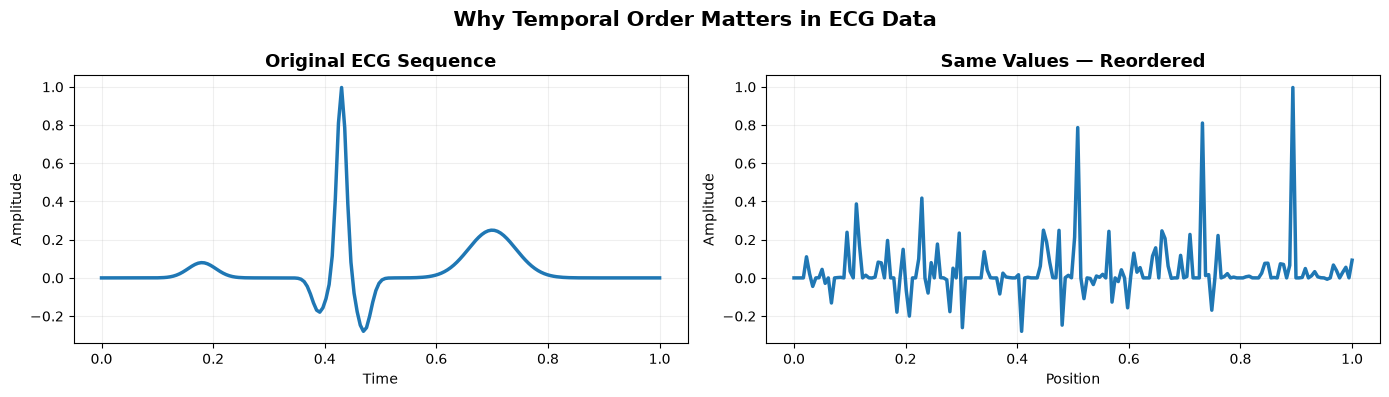

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Create a simple ECG-like heartbeat
x = np.linspace(0, 1, 180)

heartbeat = (
    0.08 * np.exp(-((x - 0.18) / 0.035) ** 2)      # P wave
    - 0.18 * np.exp(-((x - 0.39) / 0.018) ** 2)    # Q wave
    + 1.00 * np.exp(-((x - 0.43) / 0.012) ** 2)    # R peak
    - 0.28 * np.exp(-((x - 0.47) / 0.018) ** 2)    # S wave
    + 0.25 * np.exp(-((x - 0.70) / 0.060) ** 2)    # T wave
)

# Break the temporal order while keeping the same values
rng = np.random.default_rng(42)
reordered = rng.permutation(heartbeat)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Correct temporal order
axes[0].plot(x, heartbeat, linewidth=2.5)
axes[0].set_title("Original ECG Sequence", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.2)

# Same values, wrong order
axes[1].plot(x, reordered, linewidth=2.5)
axes[1].set_title("Same Values — Reordered", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.2)

plt.suptitle(
    "Why Temporal Order Matters in ECG Data",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

<div style="
    background:#FFF7ED;
    border-left:4px solid #F97316;
    border-radius:10px;
    padding:13px 16px;
    margin:14px 0 22px 0;
">

<b style="color:#C2410C;">What does this demonstrate?</b>

<span style="color:#334155;">
Both plots contain the <b style="color:#7C3AED;">same signal values</b>,
but only the first preserves their original temporal order.
Once the measurements are rearranged, the recognizable heartbeat structure disappears.
This demonstrates why an ECG should be treated as a
<b style="color:#059669;">sequence</b> rather than an unordered collection of features.
</span>

</div>

<div style="
    background:#FDF2F8;
    border-left:5px solid #EC4899;
    border-radius:12px;
    padding:15px 18px;
    margin:22px 0 12px 0;
">

<h2 style="color:#DB2777; margin:0 0 6px 0;">
2. Recurrent Neural Networks (RNNs)
</h2>

<p style="color:#334155; margin:0;">
A <b style="color:#DB2777;">Recurrent Neural Network (RNN)</b>
is designed to process sequential data while keeping information from
previous time steps through a <b style="color:#7C3AED;">hidden state</b>.
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #E2E8F0;
    border-radius:12px;
    padding:16px 18px;
    margin:12px 0;
">

<h3 style="color:#1E293B; margin-top:0;">
Processing a Sequence Step by Step
</h3>

<p style="color:#334155;">
Unlike a standard feedforward network that receives all features without
explicit temporal memory, an RNN processes a sequence
<b style="color:#2563EB;">one time step at a time</b>.
</p>

<p style="color:#334155;">
At each time step, the RNN receives two pieces of information:
</p>

<p>
<b style="color:#EC4899;">Current input (xₜ):</b>
the measurement at the current position in the sequence.
</p>

<p>
<b style="color:#7C3AED;">Previous hidden state (hₜ₋₁):</b>
information carried forward from earlier time steps.
</p>

<p style="color:#334155; margin-bottom:0;">
These are combined to produce a
<b style="color:#059669;">new hidden state (hₜ)</b>,
which is then passed to the next time step.
</p>

</div>

<div style="
    background:#EFF6FF;
    border:1px solid #BFDBFE;
    border-radius:12px;
    padding:15px 18px;
    margin:12px 0;
    text-align:center;
">

<p style="color:#1D4ED8; font-size:17px; margin:0;">
<b>hₜ = f(xₜ , hₜ₋₁)</b>
</p>

<p style="color:#475569; margin:8px 0 0 0;">
The current memory depends on both the
<b>current input</b> and the <b>previous memory</b>.
</p>

</div>

<div style="
    background:#F5F3FF;
    border:1px solid #DDD6FE;
    border-radius:12px;
    padding:16px 18px;
    margin:14px 0;
">

<h3 style="color:#7C3AED; margin-top:0;">
What Is the Hidden State?
</h3>

<p style="color:#334155;">
The <b style="color:#7C3AED;">hidden state</b> acts as the RNN's
short-term memory. It summarizes information from the sequence that has
already been processed.
</p>

<p style="color:#334155;">
For example, when the RNN reaches a later ECG measurement, its hidden
state contains information influenced by measurements that appeared earlier
in the heartbeat.
</p>

<p style="color:#334155; margin-bottom:0;">
This allows the interpretation of the current measurement to depend on its
<b style="color:#EC4899;">temporal context</b>, rather than treating it as an
isolated value.
</p>

</div>

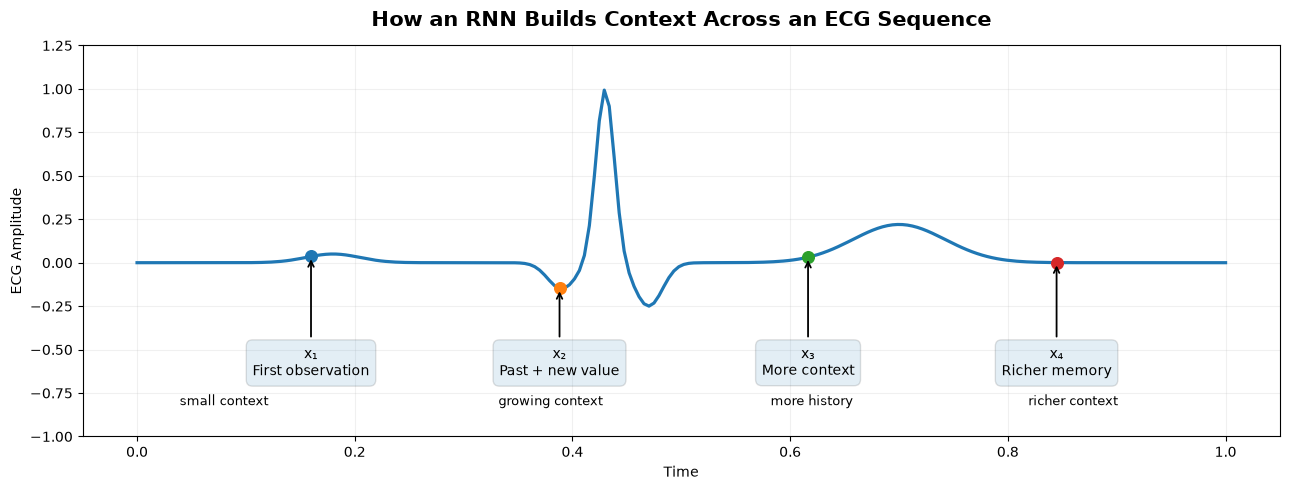

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Create a simple ECG-like waveform
x = np.linspace(0, 1, 220)

ecg = (
    0.05 * np.exp(-((x - 0.18) / 0.035) ** 2)
    - 0.15 * np.exp(-((x - 0.39) / 0.018) ** 2)
    + 1.00 * np.exp(-((x - 0.43) / 0.012) ** 2)
    - 0.25 * np.exp(-((x - 0.47) / 0.018) ** 2)
    + 0.22 * np.exp(-((x - 0.70) / 0.060) ** 2)
)

fig, ax = plt.subplots(figsize=(13, 5))

# ECG signal
ax.plot(x, ecg, linewidth=2.3)

# Selected time steps
checkpoints = [35, 85, 135, 185]

labels = [
    "x₁\nFirst observation",
    "x₂\nPast + new value",
    "x₃\nMore context",
    "x₄\nRicher memory"
]

for i, (idx, label) in enumerate(zip(checkpoints, labels), start=1):

    xp = x[idx]
    yp = ecg[idx]

    # Mark selected point
    ax.scatter(xp, yp, s=70, zorder=3)

    # Connect the ECG point to its memory note
    ax.annotate(
        label,
        xy=(xp, yp),
        xytext=(xp, -0.48),
        ha="center",
        va="top",
        fontsize=10,
        arrowprops=dict(
            arrowstyle="->",
            lw=1.3
        ),
        bbox=dict(
            boxstyle="round,pad=0.45",
            alpha=0.12
        )
    )

# Memory progression labels
ax.text(
    0.08, -0.82,
    "small context",
    fontsize=9,
    ha="center"
)

ax.text(
    0.38, -0.82,
    "growing context",
    fontsize=9,
    ha="center"
)

ax.text(
    0.62, -0.82,
    "more history",
    fontsize=9,
    ha="center"
)

ax.text(
    0.86, -0.82,
    "richer context",
    fontsize=9,
    ha="center"
)

ax.set_title(
    "How an RNN Builds Context Across an ECG Sequence",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Time")
ax.set_ylabel("ECG Amplitude")

ax.set_ylim(-1.0, 1.25)
ax.grid(alpha=0.18)

plt.tight_layout()
plt.show()

<div style="
    background:#F5F3FF;
    border-left:4px solid #8B5CF6;
    border-radius:10px;
    padding:13px 16px;
    margin:12px 0 20px 0;
">

<b style="color:#7C3AED;">🧠 Follow the context:</b>

<span style="color:#334155;">
As the RNN moves forward through the ECG sequence, each new measurement is processed together with information carried from earlier time steps.
The hidden state therefore becomes a progressively richer summary of the sequence.
</span>

</div>

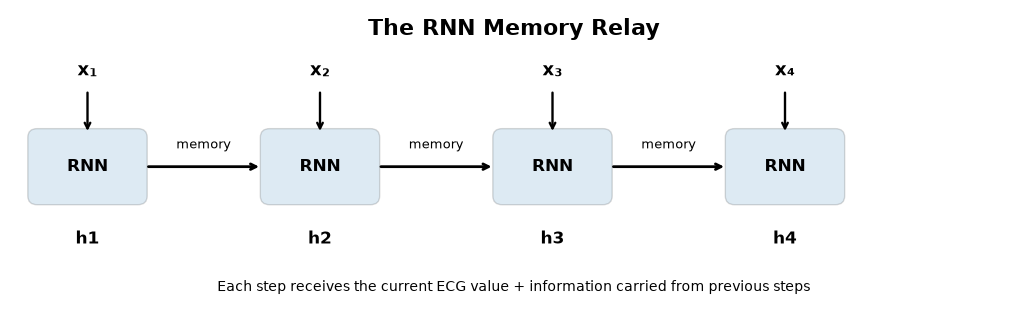

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 3.8))
ax.set_xlim(0, 13)
ax.set_ylim(0, 4)
ax.axis("off")

steps = [
    (1.0, "x₁", "ECG\nValue"),
    (4.0, "x₂", "ECG\nValue"),
    (7.0, "x₃", "ECG\nValue"),
    (10.0, "x₄", "ECG\nValue")
]

for i, (x, label, text) in enumerate(steps):
    
    # Input
    ax.text(
        x, 3.1, label,
        ha="center",
        fontsize=13,
        fontweight="bold"
    )

    # RNN cell
    box = FancyBboxPatch(
        (x - 0.65, 1.45),
        1.3, 0.8,
        boxstyle="round,pad=0.12",
        alpha=0.15
    )
    ax.add_patch(box)

    ax.text(
        x, 1.85,
        "RNN",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

    # Input arrow
    ax.annotate(
        "",
        xy=(x, 2.3),
        xytext=(x, 2.9),
        arrowprops=dict(arrowstyle="->", lw=1.7)
    )

    # Hidden state
    ax.text(
        x, 0.8,
        f"h{i+1}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

    # Memory passed forward
    if i < len(steps) - 1:
        next_x = steps[i + 1][0]

        ax.annotate(
            "",
            xy=(next_x - 0.75, 1.85),
            xytext=(x + 0.75, 1.85),
            arrowprops=dict(arrowstyle="->", lw=2)
        )

        ax.text(
            (x + next_x) / 2,
            2.1,
            "memory",
            ha="center",
            fontsize=9
        )

ax.text(
    6.5, 3.65,
    "The RNN Memory Relay",
    ha="center",
    fontsize=16,
    fontweight="bold"
)

ax.text(
    6.5, 0.15,
    "Each step receives the current ECG value + information carried from previous steps",
    ha="center",
    fontsize=10
)

plt.show()

<div style="
    background:#F5F3FF;
    border:1px dashed #8B5CF6;
    border-radius:12px;
    padding:14px 17px;
    margin:12px 0 20px 0;
">

<b style="color:#7C3AED;">🧠 Follow the Memory</b><br><br>

<span style="color:#334155;">
When the RNN reaches <b>x₄</b>, it does not see x₄ completely in isolation.
Its hidden state has been influenced by
<b style="color:#7C3AED;">h₃ → h₂ → h₁</b>,
allowing information from earlier ECG measurements to affect the current representation.
</span>

</div>

<div style="
    background:#ECFDF5;
    border:1px solid #6EE7B7;
    border-radius:10px;
    padding:14px 16px;
    margin:14px 0;
">

<b style="color:#047857;">ECG connection:</b>

<span style="color:#334155;">
For an ECG heartbeat, the sequence can be viewed as
<b style="color:#2563EB;">x₁, x₂, x₃, ... , xₜ</b>,
where each x represents the signal amplitude at a particular time step.

As the RNN moves through the heartbeat, its
<b style="color:#7C3AED;">hidden state</b>
carries information from earlier parts of the waveform, allowing later
measurements to be interpreted in the context of what came before.
</span>

</div>

<div style="
    background:#FEF2F2;
    border-left:4px solid #EF4444;
    border-radius:10px;
    padding:13px 16px;
    margin:14px 0;
">

<b style="color:#B91C1C;">Key idea:</b>

<span style="color:#7F1D1D;">
An RNN does not process each time step independently.
Its <b>hidden state</b> creates a connection between the past and the
current step, giving the network a form of memory.
</span>

</div>

<div style="
    background:#FFF7ED;
    border-left:4px solid #F97316;
    border-radius:10px;
    padding:14px 16px;
    margin:14px 0 22px 0;
">

<b style="color:#C2410C;">But there is a limitation...</b>

<span style="color:#334155;">
In theory, an RNN can carry information across an entire sequence.
In practice, information from much earlier time steps can become difficult
to learn and preserve during training.

This leads to one of the main weaknesses of plain RNNs:
<b style="color:#DC2626;">the vanishing gradient problem</b>.
</span>

</div>

<div style="
    background:#EFF6FF;
    border-left:5px solid #3B82F6;
    border-radius:12px;
    padding:15px 18px;
    margin:22px 0 12px 0;
">

<h2 style="color:#1D4ED8; margin:0 0 6px 0;">
3. The Vanishing Gradient Problem
</h2>

<p style="color:#334155; margin:0;">
Plain RNNs can pass information through a sequence,
but learning from very distant time steps becomes difficult as the sequence gets longer.
</p>

</div>

<div style="
    background:#FFF7ED;
    border:1px solid #FDBA74;
    border-radius:12px;
    padding:15px 18px;
    margin:14px 0;
">

<b style="color:#C2410C;">👀 Watch What Happens to Old Information</b>

<p style="color:#334155; margin-bottom:0;">
Imagine that an important ECG pattern appeared near the
<b style="color:#7C3AED;">beginning</b> of a long sequence.

Will that early information still strongly influence learning many time steps later?
</p>

</div>

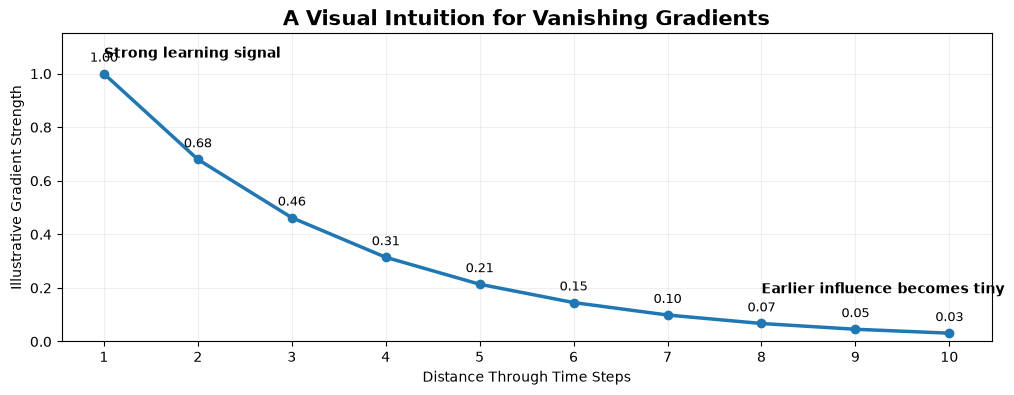

In [3]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(1, 11)

# Illustrative decay only — not a measured training gradient
signal_strength = 0.68 ** (steps - 1)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    steps,
    signal_strength,
    marker="o",
    linewidth=2.5
)

for x, y in zip(steps, signal_strength):
    ax.text(
        x,
        y + 0.045,
        f"{y:.2f}",
        ha="center",
        fontsize=9
    )

ax.set_title(
    "A Visual Intuition for Vanishing Gradients",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Distance Through Time Steps")
ax.set_ylabel("Illustrative Gradient Strength")

ax.set_xticks(steps)
ax.set_ylim(0, 1.15)
ax.grid(alpha=0.2)

ax.text(
    1,
    1.06,
    "Strong learning signal",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    8,
    0.18,
    "Earlier influence becomes tiny",
    fontsize=10,
    fontweight="bold"
)

plt.show()

<div style="
    background:#F8FAFC;
    border-left:4px solid #64748B;
    border-radius:10px;
    padding:12px 15px;
    margin:10px 0 18px 0;
">

<b style="color:#475569;">Reading the visual:</b>

<span style="color:#334155;">
The numbers above are only a simplified illustration of the idea.
They are not gradients measured from the ECG model.

The important pattern is that a learning signal repeatedly multiplied by small values
can become <b style="color:#DC2626;">smaller and smaller</b>
as it travels backward through many time steps.
</span>

</div>

<div style="
    background:#FEF2F2;
    border:1px solid #FECACA;
    border-radius:12px;
    padding:16px 18px;
    margin:14px 0;
">

<h3 style="color:#B91C1C; margin-top:0;">
So... What Is Vanishing Gradient?
</h3>

<p style="color:#334155;">
During training, a neural network learns by sending
<b style="color:#2563EB;">gradients backward</b>
through the network to update its weights.
</p>

<p style="color:#334155;">
In a plain RNN, this gradient must also travel backward through many
<b style="color:#7C3AED;">time steps</b>.
When it is repeatedly multiplied by small values,
the gradient can shrink until it becomes extremely close to zero.
</p>

<p style="color:#334155; margin-bottom:0;">
This is called the
<b style="color:#DC2626;">vanishing gradient problem</b>.
</p>

</div>

<div style="
    background:#F5F3FF;
    border:1px dashed #8B5CF6;
    border-radius:12px;
    padding:15px 18px;
    margin:14px 0;
">

<b style="color:#7C3AED;">🧠 Why Does This Hurt Memory?</b>

<p style="color:#334155;">
If the gradient reaching an earlier time step becomes extremely small,
the weights responsible for that earlier information receive
<b style="color:#DC2626;">almost no meaningful update</b>.
</p>

<p style="color:#334155; margin-bottom:0;">
As a result, the RNN becomes much better at learning
<b style="color:#059669;">recent dependencies</b>
than relationships that span a long distance through the sequence.
</p>

</div>

<div style="
    background:#ECFDF5;
    border:1px solid #6EE7B7;
    border-radius:12px;
    padding:15px 18px;
    margin:14px 0;
">

<b style="color:#047857;">❤️ Imagine This in an ECG Sequence</b>

<p style="color:#334155;">
Suppose an informative shape occurs early in the heartbeat,
while another important measurement appears much later.
</p>

<p style="color:#334155;">
To learn a relationship between them, the model needs information from the later part
to influence how earlier parts are learned.
</p>

<p style="color:#334155; margin-bottom:0;">
If that learning signal fades too much while traveling backward,
a plain RNN may struggle to capture the
<b style="color:#7C3AED;">long-term dependency</b>
between distant parts of the sequence.
</p>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #E2E8F0;
    border-radius:14px;
    padding:18px;
    margin:14px 0;
    text-align:center;
">

<h3 style="color:#1E293B; margin-top:0;">
Memory Across a Long Sequence
</h3>

<p style="font-size:17px; line-height:2;">
<span style="opacity:1;"><b>Important Past</b></span>
&nbsp;→&nbsp;
<span style="opacity:.80;">Memory</span>
&nbsp;→&nbsp;
<span style="opacity:.60;">Memory</span>
&nbsp;→&nbsp;
<span style="opacity:.40;">Memory</span>
&nbsp;→&nbsp;
<span style="opacity:.20;">Memory</span>
&nbsp;→&nbsp;
<span style="opacity:.10;">Almost Lost</span>
</p>

<p style="color:#64748B; margin-bottom:0;">
The farther information is from the current step,
the harder it may be for a plain RNN to learn its influence.
</p>

</div>

<div style="
    background:#FFF7ED;
    border-left:4px solid #F97316;
    border-radius:10px;
    padding:14px 16px;
    margin:16px 0 24px 0;
">

<b style="color:#C2410C;">So how can we stop useful information from fading?</b>

<span style="color:#334155;">
We need a recurrent architecture that can control
what information should be <b style="color:#059669;">kept</b>,
what should be <b style="color:#DC2626;">forgotten</b>,
and what new information should be <b style="color:#7C3AED;">stored</b>.

That is exactly what
<b style="color:#2563EB;">LSTM</b>
was designed to do.
</span>

</div>

<div style="
    background:#ECFDF5;
    border-left:5px solid #10B981;
    border-radius:12px;
    padding:15px 18px;
    margin:22px 0 12px 0;
">

<h2 style="color:#047857; margin:0 0 8px 0;">
4. LSTMs & GRUs — Gated Memory
</h2>

<p style="color:#334155; margin:0;">
<b style="color:#059669;">Long Short-Term Memory (LSTM)</b>
is a special type of RNN designed to handle long-term dependencies.

Instead of relying only on a hidden state, it uses a
<b style="color:#7C3AED;">memory cell and gates</b>
to control the flow of information through the sequence.
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #E2E8F0;
    border-radius:14px;
    padding:18px;
    margin:14px 0;
">

<h3 style="color:#1E293B; text-align:center; margin-top:0;">
🧠 LSTM Memory Control Room
</h3>

<div style="
    display:flex;
    gap:12px;
    justify-content:center;
    flex-wrap:wrap;
    margin-top:16px;
">

<div style="
    background:#FEF2F2;
    border:1px solid #FECACA;
    border-radius:10px;
    padding:12px;
    width:180px;
    text-align:center;
">
<b style="color:#DC2626;">🗑 Forget Gate</b><br><br>
<span style="color:#475569;">
What old information is no longer useful?
</span>
</div>

<div style="
    background:#ECFDF5;
    border:1px solid #A7F3D0;
    border-radius:10px;
    padding:12px;
    width:180px;
    text-align:center;
">
<b style="color:#059669;">📥 Input Gate</b><br><br>
<span style="color:#475569;">
What new information should be stored?
</span>
</div>

<div style="
    background:#EFF6FF;
    border:1px solid #BFDBFE;
    border-radius:10px;
    padding:12px;
    width:180px;
    text-align:center;
">
<b style="color:#2563EB;">📤 Output Gate</b><br><br>
<span style="color:#475569;">
What information should be passed forward?
</span>
</div>

</div>
</div>

<div style="
    background:#F5F3FF;
    border:1px dashed #8B5CF6;
    border-radius:12px;
    padding:15px 18px;
    margin:14px 0;
">

<b style="color:#7C3AED;">RNN vs LSTM</b><br><br>

<span style="color:#EC4899;"><b>Plain RNN:</b></span>
passes a hidden state from one time step to the next, but may struggle with distant information.
<br><br>

<span style="color:#059669;"><b>LSTM:</b></span>
uses gates and a memory cell to control what should be remembered or forgotten,
making long-term dependencies easier to learn.

</div>

<div style="
    background:#ECFDF5;
    border-left:4px solid #10B981;
    border-radius:10px;
    padding:13px 16px;
    margin:14px 0;
">

<b style="color:#047857;">❤️ ECG Connection:</b>

<span style="color:#334155;">
While reading an ECG sequence, an LSTM can preserve useful information from
earlier parts of the waveform while filtering less useful information.

This makes it suitable for learning
<b style="color:#7C3AED;">temporal patterns</b>
across a heartbeat.
</span>

</div>

<div style="
    background:#FFF7ED;
    border-left:4px solid #F97316;
    border-radius:10px;
    padding:13px 16px;
    margin:14px 0;
">

<b style="color:#C2410C;">What about GRU?</b>

<span style="color:#334155;">
A <b style="color:#EA580C;">GRU (Gated Recurrent Unit)</b>
uses the same general idea of gated memory, but with a simpler architecture
and fewer gates than an LSTM.

It is often faster to train while still handling long-term dependencies effectively.
</span>

</div>

<div style="
    background:#FEF2F2;
    border-left:4px solid #EF4444;
    border-radius:10px;
    padding:13px 16px;
    margin:14px 0 22px 0;
">

<b style="color:#B91C1C;">Remember:</b>

<span style="color:#334155;">
RNN carries memory → LSTM <b>controls</b> memory → GRU provides a simpler gated alternative.
</span>

</div>

<div style="
    background:#FFF7ED;
    border-left:5px solid #F97316;
    border-radius:12px;
    padding:15px 18px;
    margin:22px 0 12px 0;
">

<h2 style="color:#EA580C; margin:0 0 8px 0;">
5. Embeddings for Sequential Data
</h2>

<p style="color:#334155; margin:0;">
Neural networks cannot understand words directly.
An <b style="color:#EA580C;">Embedding</b> converts discrete items such as words
into dense numerical vectors that a model can learn from.
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #E2E8F0;
    border-radius:14px;
    padding:20px;
    margin:14px 0;
    text-align:center;
">

<h3 style="color:#1E293B; margin-top:0; margin-bottom:22px;">
From Words to Learnable Numbers
</h3>

<p style="font-size:16px; line-height:2.5;">

<span style="
    background:#FCE7F3;
    color:#BE185D;
    padding:8px 14px;
    border-radius:8px;
    font-weight:bold;
">
"heart"
</span>

&nbsp;&nbsp; → &nbsp;&nbsp;

<span style="
    background:#F5F3FF;
    color:#7C3AED;
    padding:8px 14px;
    border-radius:8px;
    font-weight:bold;
">
Embedding Layer
</span>

&nbsp;&nbsp; → &nbsp;&nbsp;

<span style="
    background:#ECFDF5;
    color:#047857;
    padding:8px 14px;
    border-radius:8px;
    font-weight:bold;
">
[0.21, -0.47, 0.83, ...]
</span>

</p>

<p style="color:#64748B; margin-top:15px; margin-bottom:0;">
The vector representation is learned during training.
</p>

</div>

<div style="
    background:#EFF6FF;
    border-left:4px solid #3B82F6;
    border-radius:10px;
    padding:14px 16px;
    margin:14px 0;
">

<b style="color:#1D4ED8;">Do we need Embeddings for our ECG model?</b>

<p style="color:#334155; margin-bottom:0;">
<b style="color:#DC2626;">No.</b>
Our ECG sequences already consist of
<b style="color:#059669;">numerical signal measurements</b>.

Embeddings are useful when discrete tokens, such as words, must first be
converted into learned numerical representations.
Therefore, our ECG sequence can be passed to the recurrent model
without an Embedding layer.
</p>

</div>

<div style="
    background:linear-gradient(135deg,#F5F3FF,#ECFDF5);
    border:1px solid #DDD6FE;
    border-radius:14px;
    padding:17px 20px;
    margin:18px 0 26px 0;
">

<h3 style="color:#1E293B; margin-top:0;">
✨ Before We Build the Model...
</h3>

<p style="color:#334155; line-height:1.9; margin-bottom:0;">
<b style="color:#2563EB;">Sequential data</b> → order matters<br>
<b style="color:#EC4899;">RNN</b> → carries information through a hidden state<br>
<b style="color:#DC2626;">Vanishing gradient</b> → makes distant dependencies difficult to learn<br>
<b style="color:#059669;">LSTM</b> → uses gated memory to preserve useful information<br>
<b style="color:#EA580C;">Embedding</b> → represents discrete tokens numerically, but is not needed for our ECG signals
</p>

</div>

<div style="
    background:linear-gradient(135deg,#EEF2FF,#ECFDF5);
    border:1px solid #C7D2FE;
    border-radius:18px;
    padding:24px 26px;
    margin:28px 0 20px 0;
">

<span style="color:#7C3AED; font-size:13px; font-weight:700;">
HANDS-ON LAB
</span>

<h1 style="color:#1E293B; margin:7px 0;">
ECG Heartbeat Classification
</h1>

<p style="color:#475569; margin:0;">
Applying sequence modeling concepts to real ECG heartbeat signals using
RNN and LSTM architectures.
</p>

</div>

<div style="
    background:#F5F3FF;
    border-left:5px solid #8B5CF6;
    border-radius:12px;
    padding:15px 18px;
    margin:18px 0 12px 0;
">

<h2 style="color:#7C3AED; margin:0 0 6px 0;">
Step 1 — Load & Understand the ECG Dataset
</h2>

<p style="color:#334155; margin:0;">
Before building a sequence model, the dataset is loaded and inspected to understand
its structure, dimensions, and heartbeat classes.
</p>

</div>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_df = pd.read_csv("mitbih_train.csv", header=None)
test_df = pd.read_csv("mitbih_test.csv", header=None)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (87554, 188)
Testing shape: (21892, 188)


In [5]:
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<div style="
    background:#EFF6FF;
    border-left:4px solid #3B82F6;
    border-radius:10px;
    padding:13px 16px;
    margin:14px 0;
">

<b style="color:#1D4ED8;">Understanding the Structure</b>

<p style="color:#334155; margin-bottom:0;">
Each row represents <b>one ECG heartbeat</b>.
The first <b style="color:#7C3AED;">187 values</b> form the ordered ECG sequence,
while the final column stores the
<b style="color:#059669;">heartbeat class label</b>.
</p>

</div>

In [6]:
print("Training samples:", train_df.shape[0])
print("Test samples:", test_df.shape[0])
print("Sequence length:", train_df.shape[1] - 1)

print("\nHeartbeat classes:")
print(sorted(train_df.iloc[:, -1].unique()))

Training samples: 87554
Test samples: 21892
Sequence length: 187

Heartbeat classes:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


<div style="
    background:#FFF7ED;
    border-left:4px solid #F97316;
    border-radius:10px;
    padding:13px 16px;
    margin:16px 0 12px 0;
">

<b style="color:#C2410C;">🔎 Before Modeling: Are the Classes Balanced?</b>

<span style="color:#334155;">
Before training the RNN and LSTM models, the distribution of heartbeat classes
should be examined. A strong class imbalance could make accuracy alone
misleading when evaluating the models.
</span>

</div>

In [7]:
class_counts = train_df.iloc[:, -1].value_counts().sort_index()

class_distribution = pd.DataFrame({
    "Class": class_counts.index.astype(int),
    "Samples": class_counts.values,
    "Percentage": (class_counts.values / len(train_df) * 100).round(2)
})

class_distribution

,Class,Samples,Percentage
0,0,72471,82.77
1,1,2223,2.54
2,2,5788,6.61
3,3,641,0.73
4,4,6431,7.35


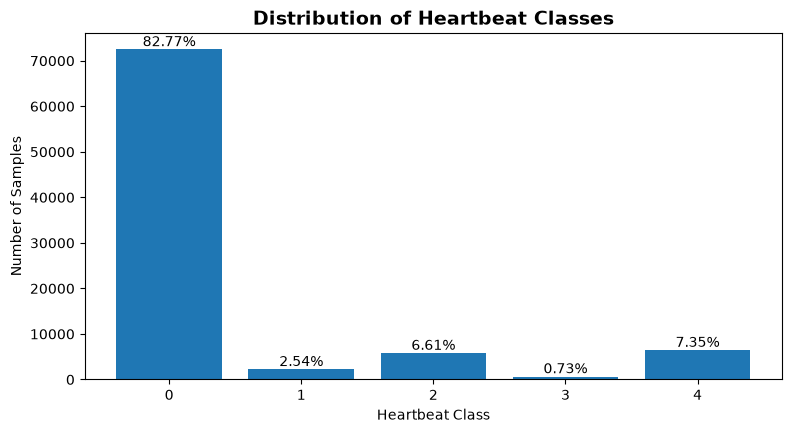

In [8]:
plt.figure(figsize=(9, 4.5))

bars = plt.bar(
    class_distribution["Class"].astype(str),
    class_distribution["Samples"]
)

plt.title(
    "Distribution of Heartbeat Classes",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Heartbeat Class")
plt.ylabel("Number of Samples")

for bar, percentage in zip(bars, class_distribution["Percentage"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()

<div style="
    background:#FEF2F2;
    border-left:4px solid #EF4444;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 22px 0;
">

<b style="color:#B91C1C;">📌 Observation:</b>

<span style="color:#334155;">
The training dataset is <b style="color:#DC2626;">highly imbalanced</b>.
Class 0 dominates the dataset with <b>82.77%</b> of all training samples,
while Class 3 represents only <b>0.73%</b>.

Because of this imbalance, overall accuracy alone may hide poor performance
on minority heartbeat classes. Therefore, class-level metrics will also be
considered when comparing the RNN and LSTM models.
</span>

</div>

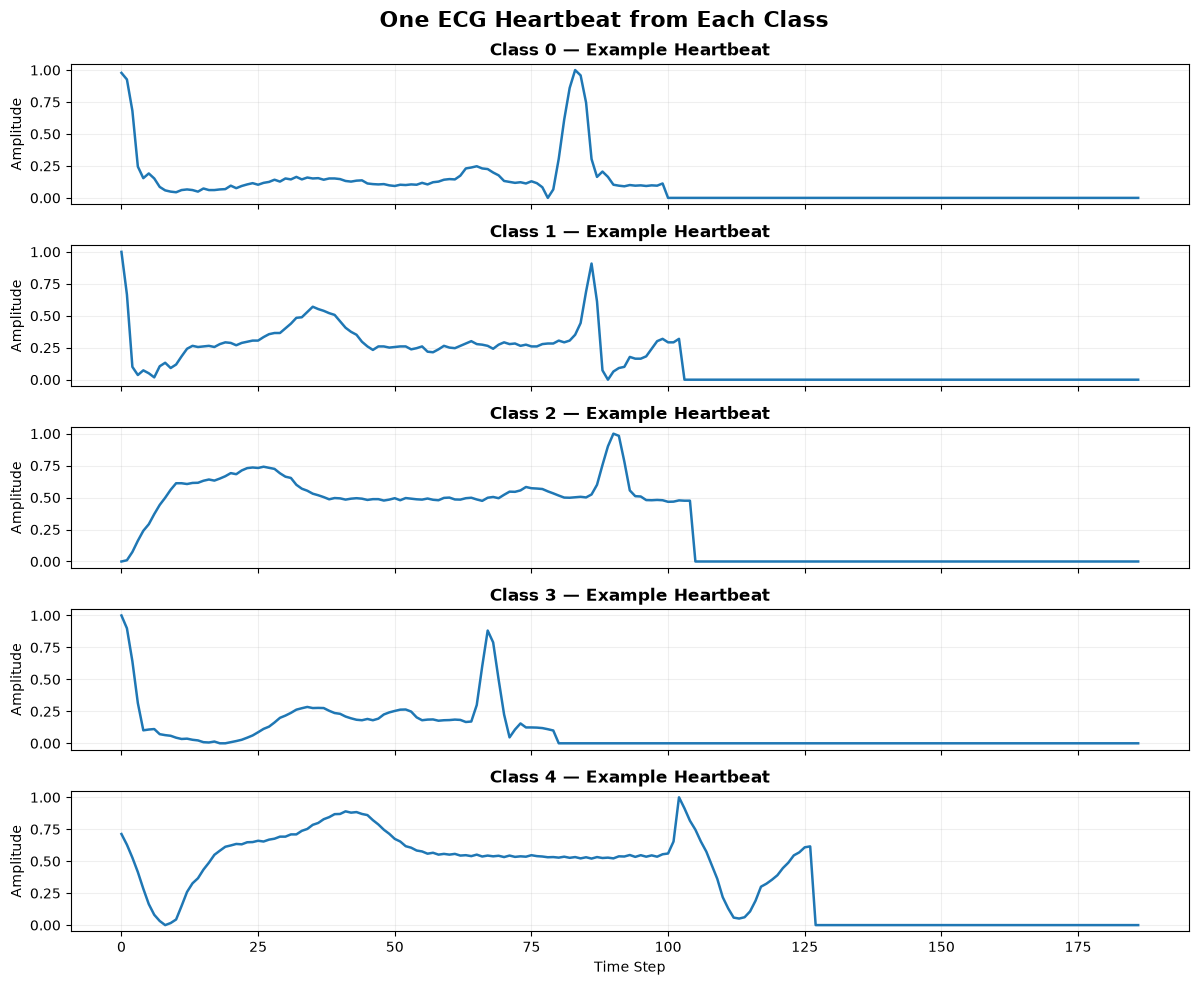

In [9]:
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

for class_id in range(5):
    sample = train_df[train_df.iloc[:, -1] == class_id].iloc[0, :-1]

    axes[class_id].plot(sample.values, linewidth=1.8)
    axes[class_id].set_title(
        f"Class {class_id} — Example Heartbeat",
        fontweight="bold"
    )
    axes[class_id].set_ylabel("Amplitude")
    axes[class_id].grid(alpha=0.2)

axes[-1].set_xlabel("Time Step")

plt.suptitle(
    "One ECG Heartbeat from Each Class",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

<div style="
    background:#ECFDF5;
    border-left:4px solid #10B981;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 22px 0;
">

<b style="color:#047857;">📌 Observation:</b>

<span style="color:#334155;">
The five heartbeat classes show visibly different
<b style="color:#7C3AED;">waveform shapes and peak patterns</b>.
These differences occur across ordered time steps, supporting the use of
<b style="color:#059669;">sequence models</b> such as RNNs and LSTMs.

The zero-valued tails are padding used to represent heartbeats with different
original lengths using a fixed sequence length of 187.
</span>

</div>

<div style="
    background:#FDF2F8;
    border-left:5px solid #EC4899;
    border-radius:12px;
    padding:15px 18px;
    margin:22px 0 12px 0;
">

<h2 style="color:#DB2777; margin:0 0 6px 0;">
Step 2 — Prepare the Data for Sequence Models
</h2>

<p style="color:#334155; margin:0;">
The ECG measurements and class labels are separated, then each heartbeat is
reshaped into the 3D format expected by recurrent neural networks.
</p>

</div>

In [10]:
# Separate ECG measurements from class labels
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values.astype(int)

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values.astype(int)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (87554, 187)
y_train: (87554,)
X_test : (21892, 187)
y_test : (21892,)


<div style="
    background:#F5F3FF;
    border:1px dashed #8B5CF6;
    border-radius:12px;
    padding:16px 18px;
    margin:14px 0;
">

<b style="color:#7C3AED;">🧩 What Shape Does an LSTM Expect?</b>

<p style="color:#334155;">
A recurrent layer expects its input in three dimensions:
</p>

<p style="text-align:center; font-size:17px;">
<b style="color:#2563EB;">Samples</b>
×
<b style="color:#EC4899;">Time Steps</b>
×
<b style="color:#059669;">Features</b>
</p>

<p style="color:#334155; text-align:center; margin-bottom:0;">
87,554 heartbeats
×
187 measurements
×
1 ECG value per time step
</p>

</div>

In [11]:
# Add one feature dimension for the ECG amplitude
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("RNN/LSTM input shape:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

RNN/LSTM input shape:
X_train: (87554, 187, 1)
X_test : (21892, 187, 1)


<div style="
    background:#FFF7ED;
    border-left:4px solid #F97316;
    border-radius:10px;
    padding:13px 16px;
    margin:14px 0;
">

<b style="color:#C2410C;">⚖ Handling Class Imbalance</b>

<span style="color:#334155;">
Because the heartbeat classes are highly imbalanced,
class weights are computed so that minority classes receive more importance
during training without changing the original sequence data.
</span>

</div>

In [12]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

class_weights

{np.int64(0): np.float64(0.24162492583240192),
 np.int64(1): np.float64(7.877103013945119),
 np.int64(2): np.float64(3.0253628196268143),
 np.int64(3): np.float64(27.317940717628705),
 np.int64(4): np.float64(2.7228735810915876)}

<div style="
    background:#ECFDF5;
    border-left:4px solid #10B981;
    border-radius:10px;
    padding:13px 16px;
    margin:12px 0 22px 0;
">

<b style="color:#047857;">📌 Observation:</b>

<span style="color:#334155;">
The computed class weights reflect the strong class imbalance.
The dominant <b>Class 0</b> receives a small weight, while rare classes,
especially <b>Class 3</b>, receive much larger weights.

These weights will make mistakes on minority heartbeat classes contribute
more strongly to the training loss.
</span>

</div>

<div style="
    background:#FDF2F8;
    border-left:5px solid #EC4899;
    border-radius:12px;
    padding:15px 18px;
    margin:22px 0 12px 0;
">

<h2 style="color:#DB2777; margin:0 0 6px 0;">
Step3 - Model Experiments — RNN & LSTM
</h2>

<p style="color:#334155; margin:0;">
Several sequential models are trained and improved gradually to compare
how well plain RNN and LSTM architectures learn ECG heartbeat patterns.
</p>

</div>

<div style="
    background:#F5F3FF;
    border-left:4px solid #8B5CF6;
    border-radius:10px;
    padding:12px 15px;
    margin:12px 0;
">

<b style="color:#6D28D9;">3.1 — Initial Plain RNN</b><br>

<span style="color:#334155;">
A simple RNN with 64 units is used as the initial sequential baseline
before applying further improvements and comparing it with LSTM.
</span>

</div>

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

tf.random.set_seed(42)

rnn_model = Sequential([
    SimpleRNN(
        64,
        input_shape=(187, 1)
    ),
    Dense(
        5,
        activation="softmax"
    )
])

rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

rnn_model.summary()

c:\Users\Bisan\miniconda3\envs\binx-ai\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,549 (17.77 KB)

 Trainable params: 4,549 (17.77 KB)

 Non-trainable params: 0 (0.00 B)

<div style="
    background:#EFF6FF;
    border-left:4px solid #3B82F6;
    border-radius:10px;
    padding:13px 16px;
    margin:12px 0 22px 0;
">

<b style="color:#1D4ED8;">📌 Model Structure:</b>

<span style="color:#334155;">
The SimpleRNN layer contains <b>64 recurrent units</b> and produces a
64-dimensional representation of each heartbeat.

The final Dense layer contains <b>5 output neurons</b>, one for each heartbeat class,
with <b style="color:#7C3AED;">softmax</b> converting the outputs into class probabilities.

The model contains <b>4,549 trainable parameters</b> in total.
</span>

</div>

In [15]:
from sklearn.model_selection import train_test_split

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training subset:", X_fit.shape)
print("Validation subset:", X_val.shape)

Training subset: (70043, 187, 1)
Validation subset: (17511, 187, 1)


In [16]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_fit)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_fit
)

class_weights = dict(zip(classes, weights))

class_weights

{np.int64(0): np.float64(0.2416234023837039),
 np.int64(1): np.float64(7.878852643419573),
 np.int64(2): np.float64(3.0256155507559397),
 np.int64(3): np.float64(27.307212475633527),
 np.int64(4): np.float64(2.722759961127308)}

In [17]:
rnn_history = rnn_model.fit(
    X_fit,
    y_fit,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 31s 57ms/step - accuracy: 0.2221 - loss: 1.7010 - val_accuracy: 0.5684 - val_loss: 1.4544
Epoch 2/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.0875 - loss: 1.6184 - val_accuracy: 0.0086 - val_loss: 1.6014
Epoch 3/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 35s 64ms/step - accuracy: 0.0897 - loss: 1.6170 - val_accuracy: 0.0101 - val_loss: 1.5979
Epoch 4/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 30s 55ms/step - accuracy: 0.0949 - loss: 1.6152 - val_accuracy: 0.0103 - val_loss: 1.5940
Epoch 5/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 47s 86ms/step - accuracy: 0.1090 - loss: 1.6121 - val_accuracy: 0.0106 - val_loss: 1.5922
Epoch 6/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 55s 100ms/step - accuracy: 0.1351 - loss: 1.6051 - val_accuracy: 0.0106 - val_loss: 1.6251
Epoch 7/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.1533 - loss: 1.5979 - val_accuracy: 0.0111 - val_loss: 1.6019
Epoch 8/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.1298 - loss: 1.5998 -

<div style="
    background:#FFF7ED;
    border-left:4px solid #F97316;
    border-radius:10px;
    padding:12px 15px;
    margin:12px 0 18px 0;
">

<b style="color:#C2410C;">📌 Observation — Initial Plain RNN</b><br>

<span style="color:#334155;">
The initial RNN showed unstable validation performance.
Although training accuracy became very high, validation accuracy dropped sharply
and remained low across later epochs.

This suggests that the plain RNN was not learning a stable representation
of the ECG sequences under the current training setup.
</span>

</div>

<div style="
    background:#EFF6FF;
    border-left:4px solid #3B82F6;
    border-radius:10px;
    padding:12px 15px;
    margin:14px 0 10px 0;
">

<b style="color:#1D4ED8;">3.2 — First RNN Improvement</b><br>

<span style="color:#334155;">
The initial RNN showed unstable validation performance.
A lower learning rate and <b>Early Stopping</b> are introduced
to improve training stability.
</span>

</div>

In [18]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

improved_rnn = Sequential([
    SimpleRNN(
        64,
        input_shape=(187, 1)
    ),
    Dense(
        5,
        activation="softmax"
    )
])

improved_rnn.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

improved_rnn_history = improved_rnn.fit(
    X_fit,
    y_fit,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20


c:\Users\Bisan\miniconda3\envs\binx-ai\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


548/548 ━━━━━━━━━━━━━━━━━━━━ 30s 52ms/step - accuracy: 0.1685 - loss: 1.3545 - val_accuracy: 0.3005 - val_loss: 1.5530
Epoch 2/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.3096 - loss: 1.2466 - val_accuracy: 0.4680 - val_loss: 1.3720
Epoch 3/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.1340 - loss: 1.5778 - val_accuracy: 0.0189 - val_loss: 1.6183
Epoch 4/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step - accuracy: 0.0921 - loss: 1.5904 - val_accuracy: 0.0210 - val_loss: 1.5904
Epoch 5/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 26s 46ms/step - accuracy: 0.1002 - loss: 1.5659 - val_accuracy: 0.0215 - val_loss: 1.5789


<div style="
    background:#FFF7ED;
    border-left:4px solid #F97316;
    border-radius:10px;
    padding:12px 15px;
    margin:12px 0 18px 0;
">

<b style="color:#C2410C;">📌 Observation — First RNN Improvement</b><br>

<span style="color:#334155;">
Lowering the learning rate and adding Early Stopping did not fully stabilize
the RNN. Validation performance still dropped sharply after the first epochs.

This suggests that the strong class weights may be making the training
too sensitive to the minority classes.
</span>

</div>

<div style="
    background:#ECFDF5;
    border-left:4px solid #10B981;
    border-radius:10px;
    padding:12px 15px;
    margin:14px 0 10px 0;
">

<b style="color:#047857;">3.3 — RNN with Softer Class Weights</b><br>

<span style="color:#334155;">
The first improvement was still unstable, suggesting that the original
class weights were too aggressive.

The class weights are therefore softened using their square roots,
and the RNN is retrained with a more balanced influence from minority classes.
</span>

</div>

In [19]:
soft_class_weights = {
    int(cls): float(np.sqrt(weight))
    for cls, weight in class_weights.items()
}

soft_class_weights

{0: 0.49155203425853494,
 1: 2.8069293976549488,
 2: 1.7394296624916856,
 3: 5.2256303424212405,
 4: 1.6500787742187668}

In [20]:
from tensorflow.keras import Input

tf.keras.backend.clear_session()
tf.random.set_seed(42)

rnn_v2 = Sequential([
    Input(shape=(187, 1)),
    SimpleRNN(64),
    Dense(5, activation="softmax")
])

rnn_v2.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping_v2 = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

rnn_v2_history = rnn_v2.fit(
    X_fit,
    y_fit,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    class_weight=soft_class_weights,
    callbacks=[early_stopping_v2],
    verbose=1
)


Epoch 1/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 27s 42ms/step - accuracy: 0.8243 - loss: 0.9751 - val_accuracy: 0.8277 - val_loss: 0.8275
Epoch 2/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.8270 - loss: 0.9638 - val_accuracy: 0.8222 - val_loss: 0.8648
Epoch 3/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 27s 50ms/step - accuracy: 0.8215 - loss: 0.9528 - val_accuracy: 0.8111 - val_loss: 0.8621
Epoch 4/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.8202 - loss: 0.9579 - val_accuracy: 0.8265 - val_loss: 0.8136
Epoch 5/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.8165 - loss: 0.9690 - val_accuracy: 0.8277 - val_loss: 0.8420
Epoch 6/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.8277 - loss: 0.9654 - val_accuracy: 0.8273 - val_loss: 0.8854
Epoch 7/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.8225 - loss: 0.9483 - val_accuracy: 0.8251 - val_loss: 0.8827
Epoch 8/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.7853 - loss: 0.8755 -

<div style="
    background:#ECFDF5;
    border-left:4px solid #10B981;
    border-radius:10px;
    padding:12px 15px;
    margin:12px 0 18px 0;
">

<b style="color:#047857;">📌 Observation — RNN with Softer Class Weights</b><br>

<span style="color:#334155;">
Softening the class weights produced a much more stable RNN training process.

The improved RNN reached a best validation accuracy of
<b>89.24%</b>, showing a clear improvement over the previous RNN experiments.

This became the strongest RNN baseline for comparison with the LSTM models.
</span>

</div>

<div style="
    background:#F5F3FF;
    border-left:4px solid #8B5CF6;
    border-radius:10px;
    padding:12px 15px;
    margin:14px 0 10px 0;
">

<b style="color:#6D28D9;">3.4 — Standard LSTM</b><br>

<span style="color:#334155;">
A standard LSTM with 64 units is now trained using the same ECG input
and softened class weights.

This experiment tests whether gated memory can model the ECG sequence
more effectively than the improved plain RNN.
</span>

</div>

In [21]:
from tensorflow.keras.layers import LSTM

tf.keras.backend.clear_session()
tf.random.set_seed(42)

lstm_model = Sequential([
    Input(shape=(187, 1)),
    LSTM(64),
    Dense(5, activation="softmax")
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

lstm_history = lstm_model.fit(
    X_fit,
    y_fit,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    class_weight=soft_class_weights,
    callbacks=[lstm_early_stopping],
    verbose=1
)

Epoch 1/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 85s 151ms/step - accuracy: 0.8215 - loss: 0.9808 - val_accuracy: 0.8008 - val_loss: 0.7852
Epoch 2/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 163s 297ms/step - accuracy: 0.8035 - loss: 0.8844 - val_accuracy: 0.8031 - val_loss: 0.7730
Epoch 3/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 123s 224ms/step - accuracy: 0.7747 - loss: 0.8330 - val_accuracy: 0.7955 - val_loss: 0.7018
Epoch 4/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 101s 184ms/step - accuracy: 0.7775 - loss: 0.8218 - val_accuracy: 0.7729 - val_loss: 0.7187
Epoch 5/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 205s 374ms/step - accuracy: 0.7889 - loss: 0.8872 - val_accuracy: 0.8277 - val_loss: 0.8202
Epoch 6/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 141s 257ms/step - accuracy: 0.7916 - loss: 0.8250 - val_accuracy: 0.8247 - val_loss: 0.6486
Epoch 7/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 242s 441ms/step - accuracy: 0.8046 - loss: 0.7548 - val_accuracy: 0.7933 - val_loss: 0.7312
Epoch 8/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 230s 419ms/step - accuracy: 0.7992 - 

In [22]:
lstm_val_loss, lstm_val_accuracy = lstm_model.evaluate(
    X_val,
    y_val,
    verbose=0
)

print("LSTM Validation Loss:", lstm_val_loss)
print("LSTM Validation Accuracy:", lstm_val_accuracy)

LSTM Validation Loss: 0.5508711338043213
LSTM Validation Accuracy: 0.8436411619186401


<div style="
    background:#FFF7ED;
    border-left:4px solid #F97316;
    border-radius:10px;
    padding:12px 15px;
    margin:12px 0 18px 0;
">

<b style="color:#C2410C;">📌 Observation — Standard LSTM</b><br>

<span style="color:#334155;">
The standard LSTM achieved a validation accuracy of
<b>84.36%</b>.

Although LSTM is designed to handle long-term dependencies,
this initial configuration did not outperform the improved RNN,
which reached <b>89.24%</b> validation accuracy.

This shows that using an LSTM does not automatically guarantee better performance,
and further tuning may be needed.
</span>

</div>

<div style="
    background:#ECFDF5;
    border-left:4px solid #10B981;
    border-radius:10px;
    padding:12px 15px;
    margin:14px 0 10px 0;
">

<b style="color:#047857;">3.5 — Tuned LSTM</b><br>

<span style="color:#334155;">
The LSTM architecture is improved by increasing model capacity and adding
<b>Dropout</b>, <b>Early Stopping</b>, and adaptive learning rate reduction.

The goal is to improve generalization and achieve more stable performance
on the ECG validation data.
</span>

</div>

In [23]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau

tf.keras.backend.clear_session()
tf.random.set_seed(42)

tuned_lstm = Sequential([
    Input(shape=(187, 1)),

    LSTM(
        128,
        return_sequences=True
    ),
    Dropout(0.20),

    LSTM(64),
    Dropout(0.20),

    Dense(32, activation="relu"),
    Dropout(0.10),

    Dense(5, activation="softmax")
])

tuned_lstm.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping_tuned = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

tuned_lstm_history = tuned_lstm.fit(
    X_fit,
    y_fit,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    class_weight=soft_class_weights,
    callbacks=[early_stopping_tuned, reduce_lr],
    verbose=1
)

Epoch 1/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 323s 584ms/step - accuracy: 0.8207 - loss: 0.9756 - val_accuracy: 0.8230 - val_loss: 0.8348 - learning_rate: 3.0000e-04
Epoch 2/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 282s 516ms/step - accuracy: 0.8071 - loss: 0.7854 - val_accuracy: 0.8599 - val_loss: 0.6355 - learning_rate: 3.0000e-04
Epoch 3/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 270s 492ms/step - accuracy: 0.8390 - loss: 0.6409 - val_accuracy: 0.8453 - val_loss: 0.5516 - learning_rate: 3.0000e-04
Epoch 4/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 258s 470ms/step - accuracy: 0.8457 - loss: 0.5806 - val_accuracy: 0.8609 - val_loss: 0.4382 - learning_rate: 3.0000e-04
Epoch 5/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 230s 420ms/step - accuracy: 0.8466 - loss: 0.5524 - val_accuracy: 0.8444 - val_loss: 0.4965 - learning_rate: 3.0000e-04
Epoch 6/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 302s 552ms/step - accuracy: 0.8608 - loss: 0.5001 - val_accuracy: 0.8738 - val_loss: 0.4034 - learning_rate: 3.0000e-04
Epoch 7/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 

<div style="
    background:#ECFDF5;
    border-left:4px solid #10B981;
    border-radius:10px;
    padding:12px 15px;
    margin:12px 0 18px 0;
">

<b style="color:#047857;">📌 Observation — Tuned LSTM</b><br>

<span style="color:#334155;">
The tuned LSTM showed a clear improvement over the previous sequential models.

Validation performance improved progressively during training, reaching
approximately <b>92.50% validation accuracy</b> with a validation loss of
<b>0.2625</b> after restoring the best model weights.

This indicates that the deeper LSTM architecture and training adjustments
provided a more effective representation of the ECG sequences.
</span>

</div>

<div style="
    background:#EFF6FF;
    border-left:5px solid #3B82F6;
    border-radius:12px;
    padding:15px 18px;
    margin:22px 0 12px 0;
">

<h2 style="color:#1D4ED8; margin:0 0 6px 0;">
Step 4 — Evaluate & Compare the Sequential Models
</h2>

<p style="color:#334155; margin:0;">
The best LSTM configuration is evaluated using validation metrics,
class-level performance, and a confusion matrix before comparing it
with the previous RNN and LSTM experiments.
</p>

</div>

<div style="
    background:#EFF6FF;
    border-left:4px solid #3B82F6;
    border-radius:10px;
    padding:13px 16px;
    margin:14px 0;
">
<b style="color:#1D4ED8;">4.1 — Evaluate the Tuned LSTM</b>

<p style="color:#334155; margin-bottom:0;">
After training the tuned LSTM, the model is evaluated on the validation set
to measure its final validation loss and accuracy using the best restored weights.
</p>

</div>

In [24]:
tuned_val_loss, tuned_val_accuracy = tuned_lstm.evaluate(
    X_val,
    y_val,
    verbose=0
)

print("Tuned LSTM Validation Loss:", tuned_val_loss)
print("Tuned LSTM Validation Accuracy:", tuned_val_accuracy)

Tuned LSTM Validation Loss: 0.2624770700931549
Tuned LSTM Validation Accuracy: 0.9249614477157593


<div style="
    background:#F0FDF4;
    border-left:4px solid #22C55E;
    border-radius:10px;
    padding:13px 16px;
    margin:14px 0;
">

<b style="color:#15803D;">4.2 — Evaluate Class-Level Performance</b>

<p style="color:#334155; margin-bottom:0;">
Because the ECG dataset is highly imbalanced, accuracy alone is not enough.
Macro F1 and the classification report are used to evaluate how well the model
performs across all heartbeat classes.
</p>

</div>

In [25]:
from sklearn.metrics import f1_score, classification_report
import numpy as np

val_probs = tuned_lstm.predict(X_val, verbose=0)
val_preds = np.argmax(val_probs, axis=1)

macro_f1 = f1_score(
    y_val,
    val_preds,
    average="macro"
)

print("Validation Macro F1:", macro_f1)
print("\nClassification Report:")
print(classification_report(
    y_val,
    val_preds,
    digits=4
))

Validation Macro F1: 0.7215895753054191

Classification Report:
              precision    recall  f1-score   support

           0     0.9709    0.9491    0.9599     14494
           1     0.5028    0.6045    0.5490       445
           2     0.7799    0.7832    0.7816      1158
           3     0.2900    0.7500    0.4183       128
           4     0.8896    0.9090    0.8992      1286

    accuracy                         0.9250     17511
   macro avg     0.6867    0.7992    0.7216     17511
weighted avg     0.9354    0.9250    0.9292     17511



<div style="
    background:#FFF7ED;
    border-left:4px solid #F97316;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 22px 0;
">

<b style="color:#C2410C;"> Validation Performance Observation</b>

<p style="color:#334155; margin-bottom:0;">
The tuned LSTM achieved <b>92.50% validation accuracy</b> with a
<b>Macro F1-score of 72.16%</b>.

Performance was strongest for Classes 0 and 4, while the minority classes
remained more challenging. In particular, Class 3 achieved high recall
but relatively low precision.

This confirms that class-level metrics provide important information
that overall accuracy alone cannot show in this imbalanced dataset.
</p>

</div>

<div style="
    background:#F5F3FF;
    border-left:4px solid #8B5CF6;
    border-radius:10px;
    padding:13px 16px;
    margin:14px 0;
">

<b style="color:#6D28D9;">4.3 — Confusion Matrix Analysis</b>

<p style="color:#334155; margin-bottom:0;">
A confusion matrix is used to examine how the tuned LSTM predictions
are distributed across the five heartbeat classes and identify
which classes are most frequently confused.
</p>

</div>

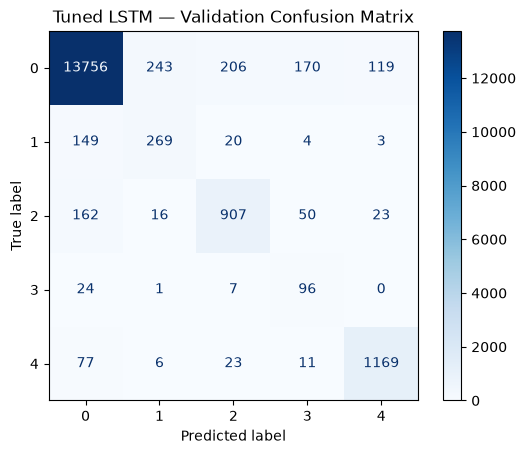

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, val_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1, 2, 3, 4]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Tuned LSTM — Validation Confusion Matrix")
plt.show()

<div style="
    background:#ECFDF5;
    border-left:4px solid #10B981;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 22px 0;
">

<b style="color:#047857;">📌 Confusion Matrix Observation</b>

<p style="color:#334155; margin-bottom:0;">
The tuned LSTM correctly classified most samples from
<b>Classes 0 and 4</b>, while Classes 1 and 3 remained more challenging.

For the rare <b>Class 3</b>, the model correctly identified
<b>96 out of 128</b> validation samples, giving relatively high recall.
However, several samples from other classes were also predicted as Class 3,
which explains its lower precision.

Overall, the confusion matrix confirms strong performance while also showing
the effect of class imbalance on the minority heartbeat classes.
</p>

</div>

<div style="
    background:#F5F3FF;
    border-left:4px solid #8B5CF6;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 22px 0;
">

<b style="color:#6D28D9;">4.4 — RNN vs LSTM Comparison</b><br><br>
<span style="color:#334155;">
The improved plain RNN achieved a best validation accuracy of
<b>89.24%</b>, while the first LSTM achieved
<b>84.36%</b>.

After further tuning, the <b>Tuned LSTM</b> achieved the strongest
validation performance with <b>92.50% accuracy</b> and a
<b>Macro F1-score of 72.16%</b>.

The tuned LSTM therefore provided the best overall validation performance
among the tested sequential models.
</span>

</div>

<div style="
    background:#EFF6FF;
    border-left:4px solid #3B82F6;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 22px 0;
">

<b style="color:#1D4ED8;">💡4.5 - Why Order-Awareness Helps with ECG</b><br><br>

<span style="color:#334155;">
ECG data is sequential, so the order of the 187 time steps carries important information.

RNNs and LSTMs process the heartbeat step by step while keeping information from previous time steps.
This allows the model to learn temporal patterns such as peaks, intervals, and waveform changes.

If the order of the ECG readings were ignored, important relationships between consecutive measurements could be lost.
</span>

</div>

<div style="
    background:#F0FDF4;
    border-left:4px solid #22C55E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 22px 0;
">

<b style="color:#15803D;">4.6 — Why LSTM Improves Over a Plain RNN</b><br><br>

<span style="color:#334155;">
A plain RNN carries information through a hidden state, but it can struggle
to preserve information across long sequences because of the
<b>vanishing gradient problem</b>.

LSTM uses gated memory to control what information should be
<b>remembered, forgotten, and passed forward</b>.

For ECG sequences with 187 time steps, this can help the model capture
longer temporal dependencies in the heartbeat waveform.
</span>

</div>

<div style="
    background:#FFF7ED;
    border-left:4px solid #F97316;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 22px 0;
">

<b style="color:#C2410C;">4.7 — Model Improvement Strategy</b><br><br>

<span style="color:#334155;">
The experiments were improved gradually rather than changing everything at once.

The process started with a <b>Plain RNN</b>, followed by adjusted class weights
to improve training stability. A standard <b>LSTM</b> was then tested,
followed by a deeper <b>Tuned LSTM</b> with additional memory capacity,
Dropout, Early Stopping, and adaptive learning rate reduction.

The final comparison was based on the validation results obtained from these experiments.
</span>

</div>

<div style="
    background:#F0FDF4;
    border-left:4px solid #22C55E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 22px 0;
">

<b style="color:#15803D;">🏁Step 5 - Final Model Evaluation on the Test Set</b><br><br>

<span style="color:#334155;">
The Tuned LSTM achieved the strongest validation performance and was selected
as the final model.

It is now evaluated once on the unseen test set to measure its final
generalization performance.
</span>

</div>

In [27]:
test_loss, test_accuracy = tuned_lstm.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.2673538029193878
Test Accuracy: 0.9235793948173523


<div style="
    background:#EFF6FF;
    border-left:4px solid #3B82F6;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 22px 0;
">

<b style="color:#1D4ED8;">5.1 — Final Class-Level Test Performance</b><br><br>

<span style="color:#334155;">
Since the ECG dataset is imbalanced, the final model is also evaluated
using Macro F1 and class-level precision, recall, and F1-score.

These metrics provide a more complete view of performance across all
five heartbeat classes.
</span>

</div>

In [28]:
test_probs = tuned_lstm.predict(X_test, verbose=0)
test_preds = np.argmax(test_probs, axis=1)

test_macro_f1 = f1_score(
    y_test,
    test_preds,
    average="macro"
)

test_weighted_f1 = f1_score(
    y_test,
    test_preds,
    average="weighted"
)

print("Test Macro F1:", test_macro_f1)
print("Test Weighted F1:", test_weighted_f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    test_preds,
    digits=4
))

Test Macro F1: 0.7152903471348148
Test Weighted F1: 0.9276832555177925

Classification Report:
              precision    recall  f1-score   support

           0     0.9700    0.9491    0.9595     18118
           1     0.4866    0.5540    0.5181       556
           2     0.7826    0.7907    0.7867      1448
           3     0.2925    0.7654    0.4232       162
           4     0.8790    0.8993    0.8890      1608

    accuracy                         0.9236     21892
   macro avg     0.6821    0.7917    0.7153     21892
weighted avg     0.9337    0.9236    0.9277     21892



<div style="
    background:#ECFDF5;
    border-left:4px solid #10B981;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 22px 0;
">

<b style="color:#047857;">🏆 Final Test Result</b><br><br>

<span style="color:#334155;">
The Tuned LSTM achieved a final <b>Test Accuracy of 92.36%</b>,
a <b>Macro F1-score of 71.53%</b>, and a
<b>Weighted F1-score of 92.77%</b>.

The test performance remained very close to the validation performance,
indicating good generalization to unseen ECG samples.

The model performed strongly on the majority classes, while the minority
classes, especially Classes 1 and 3, remained more challenging due to
the strong class imbalance in the dataset.
</span>

</div>

<div style="
    background:#F5F3FF;
    border-left:4px solid #8B5CF6;
    border-radius:10px;
    padding:13px 16px;
    margin:14px 0;
">

<b style="color:#6D28D9;">📊 Final Model Performance Comparison</b>

<p style="color:#334155; margin-bottom:0;">
The validation accuracy of the tested sequential models is compared
to highlight the improvement achieved by the final Tuned LSTM.
</p>

</div>

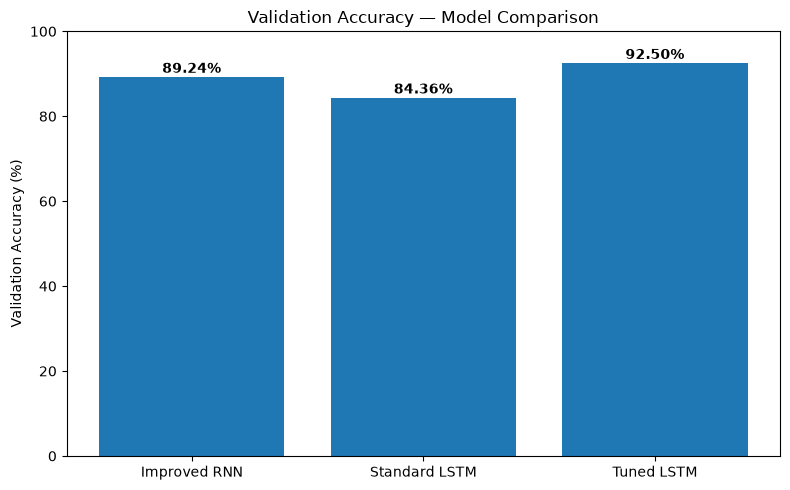

In [29]:
models = ["Improved RNN", "Standard LSTM", "Tuned LSTM"]
val_accuracies = [89.24, 84.36, 92.50]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, val_accuracies)

plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy — Model Comparison")
plt.ylim(0, 100)

for bar, accuracy in zip(bars, val_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

<div style="
    background:#ECFDF5;
    border-left:4px solid #10B981;
    border-radius:10px;
    padding:12px 15px;
    margin:12px 0 18px 0;
">

<b style="color:#047857;">📌 Comparison Observation</b><br>

<span style="color:#334155;">
The Tuned LSTM achieved the highest validation accuracy at
<b>92.50%</b>, outperforming the Improved RNN at <b>89.24%</b>
and the Standard LSTM at <b>84.36%</b>.

This supports the selection of the Tuned LSTM as the final model.
</span>

</div>

<div style="
    background:#F5F3FF;
    border-left:4px solid #8B5CF6;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 22px 0;
">

<b style="color:#6D28D9;">✨ Final Conclusion</b><br><br>

<span style="color:#334155;">
The experiments showed that sequential models can learn meaningful temporal
patterns from ECG heartbeat signals.

Among the tested models, the <b>Tuned LSTM</b> achieved the best overall
performance, reaching <b>92.36% test accuracy</b> and a
<b>71.53% Macro F1-score</b>.

The results also showed that class imbalance remains an important challenge,
especially for the minority heartbeat classes.
</span>

</div>